<a href="https://colab.research.google.com/github/edwardsnj/genomic-llms-in-practice/blob/main/Workshop/Exercise_genomic_llm_embeddings_and_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genomic LLM Interpretability: Embeddings & Token Importance — Hands-On Exercise

Here, you will need to fill in your own code in the `TODO` sections.

You will be fine-tuning the Nucleotide Transformer on an enhancer classification task, and interpreting the results.


## 1. Setup

In [1]:
# NOTE: this model ships with custom code (it needs trust_remote_code=True) that
# hasn't been updated for transformers v5 yet -- v5 removed
# find_pruneable_heads_and_indices from transformers.pytorch_utils, which the
# model's code still imports. We pin to the last 4.x line to avoid that break.
!pip install -q "transformers>=4.44,<5.0" datasets accelerate evaluate scikit-learn matplotlib

# NOTE: recent torchvision releases (0.26+) removed video-decoding APIs like
# VideoReader entirely. The `datasets` library still tries to import VideoReader
# whenever torchvision is present in the environment -- even though we're only
# working with DNA sequences and never touch video/image data. Since we don't
# need torchvision at all here, we remove it to sidestep that unrelated crash.
!pip uninstall -y -q torchvision


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import evaluate

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("GPU available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"


GPU available: True


## 2. Data and fine-tuning

We are using the **`enhancers`** task: 200bp DNA sequences labeled as enhancer (`1`) or non-enhancer (`0`).

Enhancers are regions that can boost the transcription of a nearby (or sometimes distant) gene. Unlike TATA-box promoters, they are typically defined by *combinations* of transcription factor binding motifs rather than one single, easily-spotted sequence.

In [3]:
MODEL_CHECKPOINT = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"

full_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")

# TODO (Exercise 1): filter `full_dataset` down to rows where example["task"] == "enhancers".
# Hint: full_dataset.filter(lambda example: ...)
raw_dataset = full_dataset.filter(lambda r: r["task"] == "enhancers")

raw_dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H4/train.parquet:   0%|          | 0.00/3.39M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/461850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48797 [00:00<?, ? examples/s]

Filter:   0%|          | 0/461850 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48797 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 14968
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 400
    })
})

In [4]:
train_dataset = raw_dataset["train"].shuffle(seed=SEED).select(range(1000))
eval_dataset = raw_dataset["test"].shuffle(seed=SEED).select(range(200))

print("Train examples:", len(train_dataset))
print("Eval examples:", len(eval_dataset))
print("Label distribution (train):", np.bincount(train_dataset["label"]))

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(batch):
    return tokenizer(batch["sequence"], padding="max_length", truncation=True, max_length=64)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
eval_tokenized = eval_dataset.map(tokenize_function, batched=True)
train_tokenized = train_tokenized.rename_column("label", "labels")
eval_tokenized = eval_tokenized.rename_column("label", "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]
train_tokenized.set_format(type="torch", columns=columns_to_keep)
eval_tokenized.set_format(type="torch", columns=columns_to_keep)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=2, trust_remote_code=True
).to(device)


Train examples: 1000
Eval examples: 200
Label distribution (train): [467 533]


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-50m-multi-species:
- esm_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_esm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-50m-multi-species:
- modeling_esm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Some weights of the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species were not used when initializing EsmForSequenceClassification: ['lm_head.bias', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing EsmForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species and are newly initialized: ['classifier.dense.bias', 'c

In [6]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./nt-enhancers-quick-finetune",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=25,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    compute_metrics=compute_metrics,
)

trainer.train()
print(trainer.evaluate())


Epoch,Training Loss,Validation Loss,Accuracy
1,0.363600,0.777045,0.735000
2,0.175500,1.005831,0.740000
3,0.036200,1.268808,0.745000
4,0.001700,1.557796,0.735000
5,0.000900,1.699559,0.735000
6,0.000700,1.819719,0.735000
7,0.000600,1.810934,0.735000
8,0.000500,1.865885,0.735000
9,0.000400,1.889309,0.735000
10,0.000400,1.897394,0.735000


{'eval_loss': 1.897393822669983, 'eval_accuracy': 0.735, 'eval_runtime': 0.5289, 'eval_samples_per_second': 378.144, 'eval_steps_per_second': 47.268, 'epoch': 10.0}


## 3. Extracting embeddings from every layer

`output_hidden_states=True` gives us one tensor per layer, each of shape `(batch_size, sequence_length, hidden_size)`. We mean-pool each layer's token representations into a single per-sequence vector.

**Exercise 2:** Fill in the mean-pooling step. You have:
- `layer_hidden`: shape `(batch, seq_len, hidden)` — the raw token embeddings for one layer
- `mask`: shape `(batch, seq_len, 1)` — `1` for real tokens, `0` for padding

Compute the mean over the sequence dimension, but **only over the real tokens** (ignore padding).

In [8]:
def get_layerwise_embeddings(sequences, batch_size=8, max_length=64):
    # Returns a list of arrays, one per layer, each of shape (num_sequences, hidden_size).
    model.eval()
    all_layers_embeddings = None

    for start in range(0, len(sequences), batch_size):
        batch_seqs = sequences[start:start + batch_size]
        inputs = tokenizer(
            batch_seqs, return_tensors="pt", padding="max_length",
            truncation=True, max_length=max_length,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states  # tuple: (num_layers + 1) x (batch, seq_len, hidden)
        mask = inputs["attention_mask"].unsqueeze(-1)  # (batch, seq_len, 1)

        if all_layers_embeddings is None:
            all_layers_embeddings = [[] for _ in hidden_states]

        for layer_idx, layer_hidden in enumerate(hidden_states):
            # TODO (Exercise 2): mean-pool `layer_hidden` over the sequence
            # dimension (dim=1), counting only the real (non-padding) tokens.
            # Hint: sum(layer_hidden * mask, dim=1) / sum(mask, dim=1), with the
            # denominator clamped to a minimum of 1 to avoid dividing by zero.

            summed = (layer_hidden * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1)
            pooled = (summed / counts).cpu().numpy()

            all_layers_embeddings[layer_idx].append(pooled)

    return [np.concatenate(layer_chunks, axis=0) for layer_chunks in all_layers_embeddings]


# Run on a modest subset of the eval set for speed
probe_sequences = eval_dataset["sequence"][:150]
probe_labels = np.array(eval_dataset["label"][:150])

layer_embeddings = get_layerwise_embeddings(probe_sequences)
print(f"Number of layers (including input embeddings): {len(layer_embeddings)}")
print(f"Shape of each layer's embeddings: {layer_embeddings[0].shape}")


Number of layers (including input embeddings): 13
Shape of each layer's embeddings: (150, 512)


## 4. Layer-wise probing: where does the useful signal live?

Train a small logistic regression classifier on each layer's pooled embeddings, and see how accuracy changes with depth.

**Before you run this: predict first.** Enhancers are less defined by one crisp motif than TATA-box promoters are. Do you expect the layer-wise accuracy curve to look similar to the promoter task, or different? Where do you expect the most useful signal to emerge?

**Exercise 3:** Fill in the probe training and scoring step.

In [9]:
n_probe = len(probe_labels)
split = int(n_probe * 0.7)

layer_accuracies = []
for layer_idx, embeddings in enumerate(layer_embeddings):
    X_train, X_test = embeddings[:split], embeddings[split:]
    y_train, y_test = probe_labels[:split], probe_labels[split:]

    probe = LogisticRegression(max_iter=1000)

    # TODO (Exercise 3): fit `probe` on (X_train, y_train), then compute its
    # accuracy on (X_test, y_test). Hint: probe.fit(...) and probe.score(...).
    probe.fit(X_train, y_train)
    acc = probe.score(X_test, y_test)

    layer_accuracies.append(acc)

for i, acc in enumerate(layer_accuracies):
    layer_name = "Input embeddings" if i == 0 else f"Layer {i}"
    print(f"{layer_name:>18}: {acc:.3f} accuracy")


  Input embeddings: 0.622 accuracy
           Layer 1: 0.667 accuracy
           Layer 2: 0.578 accuracy
           Layer 3: 0.622 accuracy
           Layer 4: 0.622 accuracy
           Layer 5: 0.689 accuracy
           Layer 6: 0.689 accuracy
           Layer 7: 0.689 accuracy
           Layer 8: 0.689 accuracy
           Layer 9: 0.689 accuracy
          Layer 10: 0.689 accuracy
          Layer 11: 0.667 accuracy
          Layer 12: 0.711 accuracy


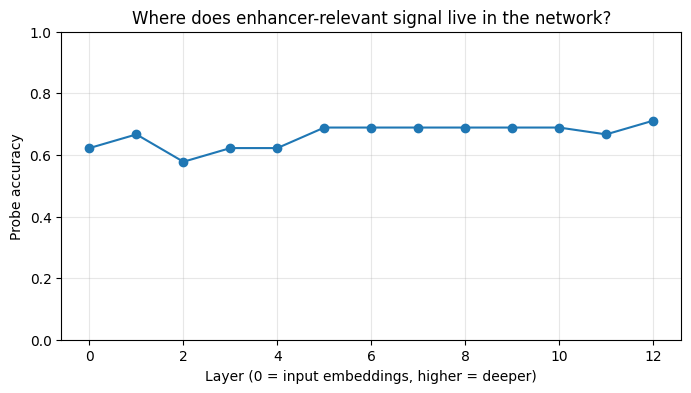

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(layer_accuracies)), layer_accuracies, marker="o")
plt.xlabel("Layer (0 = input embeddings, higher = deeper)")
plt.ylabel("Probe accuracy")
plt.title("Where does enhancer-relevant signal live in the network?")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

Compare this curve to the one from the promoter notebook. Was your prediction right?

## 5. Visualizing embeddings with PCA

**Exercise 4:** Reduce an early layer and the final layer to 2D with PCA and plot them side by side, colored by true label.

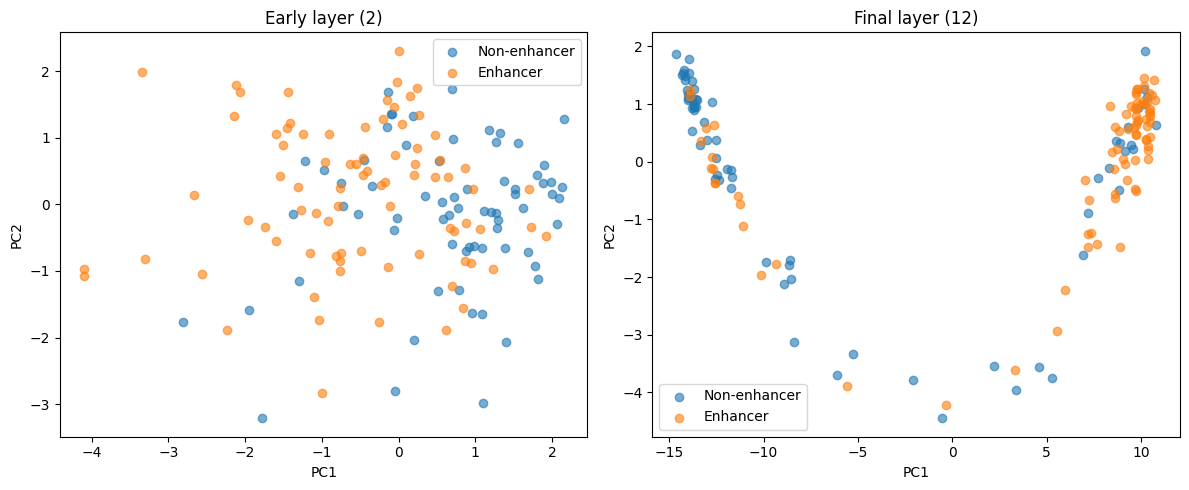

In [11]:
early_layer_idx = 2
late_layer_idx = len(layer_embeddings) - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, layer_idx, title in [
    (axes[0], early_layer_idx, f"Early layer ({early_layer_idx})"),
    (axes[1], late_layer_idx, f"Final layer ({late_layer_idx})"),
]:
    pca = PCA(n_components=2, random_state=SEED)
    # TODO (Exercise 4): fit `pca` on layer_embeddings[layer_idx] and transform
    # it down to 2D coordinates. Hint: pca.fit_transform(...).
    coords = pca.fit_transform(layer_embeddings[layer_idx])

    for label_value, label_name, color in [(0, "Non-enhancer", "tab:blue"), (1, "Enhancer", "tab:orange")]:
        mask = probe_labels == label_value
        ax.scatter(coords[mask, 0], coords[mask, 1], label=label_name, alpha=0.6, c=color)

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.tight_layout()
plt.show()


How does the separation here compare to the promoter task? Given that enhancers are a less clean-cut category biologically, would you expect *less* visual separation than promoters, even with a well-trained model?

## 6. Token importance: what is the model actually looking at?

Use the Gradient × Input approach:
1. Run the sequence through the model, take the predicted class's logit as the score
2. Backpropagate to the input embeddings
3. Multiply each token's embedding by its own gradient and sum across the hidden dimension

**Exercise 5:** Fill in:
- The forward hook (which needs to keep gradients around for a tensor produced mid-network)
- The saliency computation.

In [12]:
def compute_token_saliency(sequence: str, max_length: int = 64):
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=max_length).to(device)

    embedding_layer = model.get_input_embeddings()
    captured = {}

    def hook(module, module_input, module_output):
        # TODO (Exercise 5a): `module_output` is not a leaf tensor, so PyTorch
        # won't keep its .grad after backward() unless we ask it to. Call
        # .retain_grad() on it, then store it in captured["embeds"] so we can
        # read the gradient afterwards.

        module_output.retain_grad()
        captured["embeds"] = module_output

    handle = embedding_layer.register_forward_hook(hook)

    model.eval()
    model.zero_grad()
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = int(logits.argmax(dim=-1))
    score = logits[0, predicted_class]
    score.backward()

    embeds = captured["embeds"]              # (1, seq_len, hidden)
    grads = embeds.grad                       # (1, seq_len, hidden)

    # TODO (Exercise 5b): compute the Gradient x Input saliency score per token.
    # Multiply grads and embeds elementwise, sum over the hidden dimension
    # (dim=-1), then take the absolute value. Result shape should be (seq_len,)
    # after indexing [0].
    saliency = saliency = (grads * embeds).sum(dim=-1).abs()[0]  # (seq_len,)

    handle.remove()

    token_ids = inputs["input_ids"][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Drop special tokens (e.g. <cls>) and padding from the visualization
    keep = [i for i, t in enumerate(tokens) if t not in tokenizer.all_special_tokens]
    tokens = [tokens[i] for i in keep]
    saliency = saliency[keep]

    # Normalize to [0, 1] for coloring
    if saliency.max() > saliency.min():
        saliency_norm = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    else:
        saliency_norm = np.zeros_like(saliency)

    predicted_label = "Enhancer" if predicted_class == 1 else "Non-enhancer"
    return tokens, saliency_norm, predicted_label


In [13]:
from IPython.display import HTML, display

def render_saliency_html(tokens, saliency_norm, predicted_label):
    spans = []
    for tok, score in zip(tokens, saliency_norm):
        color = f"rgba(220, 20, 60, {score:.2f})"
        spans.append(
            f'<span style="background-color:{color}; padding:2px 3px; margin:1px; '
            f'border-radius:3px; font-family:monospace;">{tok}</span>'
        )
    html = f"<b>Prediction: {predicted_label}</b><br>" + "".join(spans)
    display(HTML(html))


# Try it on a real example from the eval set
example_idx = 0
example_sequence = eval_dataset["sequence"][example_idx]
true_label = "Enhancer" if eval_dataset["label"][example_idx] == 1 else "Non-enhancer"

tokens, saliency_norm, predicted_label = compute_token_saliency(example_sequence)
print(f"True label: {true_label}")
render_saliency_html(tokens, saliency_norm, predicted_label)


True label: Enhancer


In [14]:
# Also try it on a synthetic sequence containing the AP-1/TRE motif (TGACTCA),
# a transcription factor binding site commonly found in enhancer regions
# (though, unlike the TATA-box in promoters, no single motif defines an enhancer
# on its own -- this is just one illustrative building block).
ap1_example = ("GC" * 40 + "TGACTCA" + "GC" * 40)[:200]
tokens, saliency_norm, predicted_label = compute_token_saliency(ap1_example)
print("Synthetic sequence with an inserted AP-1 motif (TGACTCA)")
render_saliency_html(tokens, saliency_norm, predicted_label)


Synthetic sequence with an inserted AP-1 motif (TGACTCA)


**What to look for:** unlike the TATA-box case, the model's attention is more spread out across the sequence rather than sharply focused on the inserted motif. Enhancer activity typically depends on combinations of motifs and their spacing/context, not a single element, so a "cleaner" saliency pattern isn't necessarily expected here, even from a well-trained model.


## Wrap-up

You fine-tuned the Nucleotide Transformer on a new task (enhancer classification), then:
- Extracted embeddings from every layer
- Probed each layer to see where enhancer-relevant signal emerges
- Visualized the embedding separation with PCA
- Computed and visualized token-level saliency for individual predictions

## To consider in your own time

**How does this compare to the TATA promoter exercise?**
